In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import subprocess
import os
from IPython.display import Image, display

# =====================================================================
# 1. CONFIGURATION 
# =====================================================================
# Put everything between '', configurate for yourself.

# Input: 'Data_input/' when using the subfolder
FILE_PLATE_READER = 'Data_input/72hdrugs_Exp005_001.csv'
FILE_DISPENSER    = 'Data_input/20260411_1_antaognism.csv'
#Output: 'Data_output/' is for putting it into the subfolder
FILE_OUTPUT       = 'Data_output/synergy_pipeline_final.csv'
PDF_FILE_OUTPUT   = 'Data_output/Exp005'

# R-script pathway
RSCRIPT_PATH      = "C:/Program Files/R/R-4.5.3/bin/Rscript.exe"

# Lists of controls and what to remove: Leave 'Evaporation_Control' -> Important for the script
POSITIVE_CONTROLS = ['PC']        
NEGATIVE_CONTROLS = ['DMSO C', 'DMSO', 'NC']    
REMOVE_LIST       = ['Control', 'Evaporation_Control', 'Empty', 'Buffer']

# Name of the drugs
ANCHOR_DRUG       = 'Abemaciclib'     
PARTNER_DRUG      = 'Cladribine'     

# Concentrations of the drugs: it will bin them then!
TARGET_BINS = [0.0, 0.032, 0.116, 0.42, 1.52, 5.52, 20.0, 40.0, 0.08, 0.183, 0.418, 0.956, 2.19, 5.0, 10.0]
# Collection of used concentrations:
#20260401-6x6: Rab + Cyt [0.0, 0.103, 0.309, 0.926, 2.78, 8.33, 25.0, 75.0, 0.0043, 0.0129, 0.0387, 0.116, 0.347, 1.04, 3.13]
#20260401-6x6: Rab + Clad [0.0, 0.103, 0.309, 0.926, 2.78, 8.33, 25.0, 75.0, 0.0069, 0.0207, 0.062, 0.186, 0.556, 1.67, 5.0]
#20260414-6x6: Abe + Cyt [0.0, 0.032, 0.116, 0.42, 1.52, 5.52, 20.0, 40.0, 0.04, 0.0761, 0.145, 0.276, 0.525, 1.0, 5.0]
#20260414-6x6: Abe + Clad [0.0, 0.032, 0.116, 0.42, 1.52, 5.52, 20.0, 40.0, 0.08, 0.183, 0.418, 0.956, 2.19, 5.0, 10.0]
#20260413-4x4: Rab + Cyt [0.0, 0.01, 0.025, 0.0585, 0.342, 2.00, 5, 0.25, 1.00, 2.92, 8.5, 25.0, 75.0]

# You can also remove some concentrations again if they outlie
REMOVE_CONCENTRATIONS = []

In [2]:
# =====================================================================
# 2. DATA PROCESSING & MERGING
# =====================================================================
reader_df = pd.read_csv(FILE_PLATE_READER)
dispense_df = pd.read_csv(FILE_DISPENSER)

# Grab Well and Signal of the plate reader, drop empty rows
reader_clean = reader_df[['Well', 'Signal']].dropna(subset=['Signal']).copy()

# Combine combinations by the well Code (A1, A2,..., B1, B2,... .)
dispense_df['Drug_Idx'] = dispense_df.groupby(['Dispensed well']).cumcount() + 1
drugs = dispense_df.pivot(index='Dispensed well', columns='Drug_Idx', values='Fluid name')
concs = dispense_df.pivot(index='Dispensed well', columns='Drug_Idx', values='Dispensed concentration')

dispense_wide = pd.concat([drugs, concs], axis=1).reset_index().rename(columns={'Dispensed well': 'Well'})
dispense_wide.columns = ['Well'] + [f'Drug{i}' for i in drugs.columns] + [f'Conc{i}' for i in concs.columns]

merged_df = pd.merge(reader_clean, dispense_wide, on='Well', how='inner')

# Use 0.0 if column is empty

if 'Drug2' not in merged_df.columns:
    merged_df['Drug2'] = 'None'
    merged_df['Conc2'] = 0.0

merged_df['Drug1'] = merged_df['Drug1'].fillna('Evaporation_Control')
merged_df['Drug2'] = merged_df['Drug2'].fillna('None')
merged_df[['Conc1', 'Conc2']] = merged_df[['Conc1', 'Conc2']].fillna(0.0)

In [3]:
# =====================================================================
# 3. BINNING & NORMALIZATION
# =====================================================================
# Use traget bin (concentrations) to fit the concentration into one of them and then replace them

def snap(v):
    if pd.isna(v) or v == 0.0: return 0.0
    return min(TARGET_BINS, key=lambda x: abs(x - v))

merged_df['Conc1'] = merged_df['Conc1'].apply(snap)
merged_df['Conc2'] = merged_df['Conc2'].apply(snap)

merged_df = merged_df[~merged_df['Conc1'].isin(REMOVE_CONCENTRATIONS)]
merged_df = merged_df[~merged_df['Conc2'].isin(REMOVE_CONCENTRATIONS)]

# Calculate means and viability
mean_pc = merged_df[merged_df['Drug1'].isin(POSITIVE_CONTROLS)]['Signal'].mean()
mean_dmso = merged_df[merged_df['Drug1'].isin(NEGATIVE_CONTROLS)]['Signal'].mean()
merged_df['Viability_pct'] = ((merged_df['Signal'] - mean_pc) / (mean_dmso - mean_pc)) * 100

df = merged_df[~merged_df['Drug1'].isin(REMOVE_LIST)].copy()

In [4]:
# =====================================================================
# 4. STANDARDIZATION & CSV EXPORT
# =====================================================================

def standardize(row):
    if row['Drug1'] in POSITIVE_CONTROLS: return None
    d1, d2 = str(row['Drug1']), str(row['Drug2'])
    c1, c2 = row['Conc1'], row['Conc2']
    
    if d1 in NEGATIVE_CONTROLS: 
        return pd.Series([ANCHOR_DRUG, PARTNER_DRUG, 0.0, 0.0, row['Viability_pct']])
    if d1 == PARTNER_DRUG and d2 == ANCHOR_DRUG:
        return pd.Series([ANCHOR_DRUG, PARTNER_DRUG, c2, c1, row['Viability_pct']])
    if d1 == ANCHOR_DRUG and d2 == PARTNER_DRUG:
        return pd.Series([ANCHOR_DRUG, PARTNER_DRUG, c1, c2, row['Viability_pct']])
    if d1 == ANCHOR_DRUG and (d2 == 'nan' or d2 == 'None'):
        return pd.Series([ANCHOR_DRUG, PARTNER_DRUG, c1, 0.0, row['Viability_pct']])
    if d1 == PARTNER_DRUG and (d2 == 'nan' or d2 == 'None'):
        return pd.Series([ANCHOR_DRUG, PARTNER_DRUG, 0.0, c1, row['Viability_pct']])
    return None

df_final = df.apply(standardize, axis=1).dropna()
df_final.columns = ['Drug1', 'Drug2', 'Conc1', 'Conc2', 'Viability_pct']
df_final.to_csv(FILE_OUTPUT, index=False)


--- Generating Python Heatmap ---


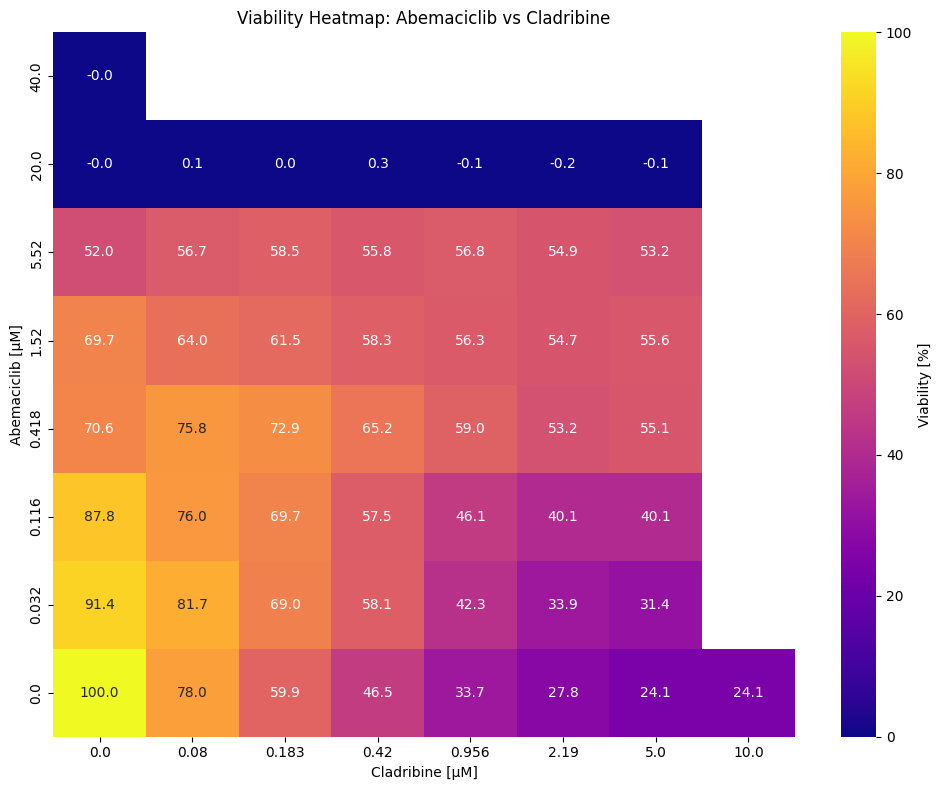

In [5]:
# =====================================================================
# 5. GENERATE PYTHON HEATMAP (SEABORN)
# =====================================================================
# Using seaborn to get a heatmap: For overfew: --> Does the data look as it was expected?
# If not --> Problems with the code!

print(f"\n--- Generating Python Heatmap ---")
pivot_data = df_final.groupby(['Conc1', 'Conc2'])['Viability_pct'].mean().unstack()
pivot_data = pivot_data.sort_index(ascending=False).sort_index(axis=1, ascending=True)

plt.figure(figsize=(10, 8))

# --- NEW: Added vmin=0 and vmax=100 to lock the color scale! ---
sns.heatmap(pivot_data, annot=True, fmt=".1f", cmap='plasma', 
            vmin=0, vmax=100, 
            cbar_kws={'label': 'Viability [%]'})

plt.title(f"Viability Heatmap: {ANCHOR_DRUG} vs {PARTNER_DRUG}")
plt.xlabel(f"{PARTNER_DRUG} [µM]")
plt.ylabel(f"{ANCHOR_DRUG} [µM]")
plt.tight_layout()

# Show the Seaborn plot in the notebook
plt.show()

In [6]:
#ACCESS R: IMPORTANT PACKAGES to install in R before!!!
# install.packages("remotes")
# remotes::install_github("ocbe-uio/bayesynergy")
# Seperate file for R: See "run_bayesynergy.R"!!!

In [ ]:
# =====================================================================
# 6. RUN R PIPELINE
# =====================================================================
# I asked LLM: Its accessing the R script:'run_bayesynergy.R' --> Im not sure what it does but it works

print(f"\n--- Starting R Pipeline ---")

if not os.path.exists("run_bayesynergy.R"):
    print("Error: Could not find 'run_bayesynergy.R' in this folder.")
else:
    command = [
        RSCRIPT_PATH, 
        "run_bayesynergy.R", 
        FILE_OUTPUT,     
        ANCHOR_DRUG,     
        PARTNER_DRUG,
        PDF_FILE_OUTPUT if PDF_FILE_OUTPUT.strip() != "" else "DEFAULT" # <--- Prevents R crash!
    ]

    try:
        result = subprocess.run(command, capture_output=True, text=True, check=True)
        print(result.stdout)
        print("Done! Check your folder for the new PDF.")
            
    except subprocess.CalledProcessError as e:
        print("An error occurred while running R:")
        print(e.stderr)


--- Starting R Pipeline ---
